# Assignment 6
### Do Question 6, and three more questions of your choice.

### 1. Set review:

- Operations on sets (hints: sketch venn-type diagrams, and showing $A=B$ is the same as $A \subseteq B$ and $B \subseteq A$):
- $ (A \backslash B) \cup (A \cap B) = A $
- $ A \cup ( B \cap C) = (A \cup B) \cap (A \cup C)$
- $ A \backslash (B \cup C) = A\backslash B \cap A \backslash C $ and $A \backslash (B \cap C) = A \backslash B \cup A \backslash C$

- Plot the following sets: 
    - $A = \{x \in \mathbb{R}: x^2 -1 \ge 0 \}$ 
    - $B = \{ (x,y) \in \mathbb{R}^2: 3x -2y \ge 0 \}$
    - $C = \{ (x,y) \in \mathbb{R}^2: xy \ge 3 \}$
    - $D = \{ (x_1,x_2) \in \mathbb{R}^2: x_1 \ge 0, x_2 \ge 0, x_1 + x_2 \le 1 \}$
- The power set of $A$ is the set of all subsets of $A$, denoted $\mathcal{P}(A)$. What is the power set of $\{ 1, 2, 3 \}$? (Hint: The empty set is a subset of every set; the whole set is a subset of itself.)

### 2. Probability space basics:

- What are the outcomes for rolling a single, fair **THREE**-sided die? What's the set of all events? What are the probabilities of all the events?

    - *The outcomes for rolling a single, fair three-sided die would be 1, 2, and 3.*
    - *The set of all events would total to 8 different events: {0}, {1}, {2}, {3}, {1, 2}, {1, 3}, {2, 3}, {1, 2, 3}.*
    - *The probabilities of all the events would be 1/3.*
- What are the outcomes for rolling a fair **THREE**-sided die? What's the set of all events? What are the probabilities of all the events?

    - *The outcomes for rolling a fair three-sided die would be 1, 2, and 3.*
    - *The set of all events would total to 8 different events: {0}, {1}, {2}, {3}, {1, 2}, {1, 3}, {2, 3}, {1, 2, 3}.*
    - *The probabilities of all the events would be 1/3.*

- What about flipping a fair coin twice? (Hint: There are 4 outcomes, and $2^{4} = 16$ events.)
    - *The outcomes for flipping a fair coin twice would be H/H, H/T, T/H, T/T.*
    - *The set of all events would be: {HH, HT}, {HH, HH}, {HH, TT}, {HH, TH}, {HT, HH}, {HT, HT}, {HT, TH}, {HT, TT}, {TH, HH}, {TH, HT}, {TH, TH}, {TH, TT}, {TT, HH}, {TT, HT}, {TT, TH}, {TT, TT}.*
    - *The probabilities of all the events would be 1/4.*

- What about rolling the **THREE**-sided die twice, and adding the results? Don't write down the set of all the possible events, but describe briefly what it looks like and how large it is. (Hint: There are 5 outcomes, and $2^{5}=32$ possible events.)

    - *The outcomes would be: {2}, {3}, {4}, {5}, {6}.*
    - *The set of all possible events would be something along the lines of {0}, {2}, {3}...{2,3}, {2,4}...{2,3,4}, {2,3,5}...{2,3,4,5}...{2,3,4,5,6}, which would total to 32 events.*
    - *The probabilities of all events would different depending on the sum (since you are rolling twice). Getting the sum of 2 would have a probability of 1/9, sum of 3 would be 2/9, sum of 4 would be 3/9, sum of 5 would be 2/9, and sum of 6 would be 1/9.*

Obviously, a "three-sided die" doesn't exist, but this keeps you from spending a lot of time suffering in working out sets of events.


### 3. Random Variable Basics

- Imagine rolling a fair single six-sided die. There are 6 outcomes, all equally likely. Derive the sample space and the space of events. What are the probabilities of the outcomes and events? 

    - *The sample space is {1,2,3,4,5,6}. The total number of events is 64 (2^6). A simple event probability would be 1/6.*
    
- Consider a random variable that assigns the square root of the number of pips on the die to each outcome. Write code to simulate rolling a single six-sided die and computing the value of the random variable. Simulate 5000 rolls and plot the mass function and ECDF of the random variable.
- Imagine rolling two fair six-sided die. Consider a random variable that adds up the pips on the dice. There are 11 outcomes (2 , 3, ..., 12), but not all are equally likely. Derive the sample space and **describe** the space of events. What are the probabilities of the outcomes?

    - *The sample space would be {2,3,4,5,6,7,8,9,10,11,12}, so there are 2048 possible events. The probabilities of the outcomes are for a sum of 2 --> 1/36, sum of 3 --> 2/36, sum of 4 --> 3/36, sum of 5 --> 4/36, sum of 6 --> 5/36, sum of 7 --> 6/36, sum of 8 --> 5/36, sum of 9 --> 4/36, sum of 10 --> 3/36, sum of 11 --> 2/36, and sum of 12 --> 1/36.*
- Write code to simulate the random variable (rolling two six-sided die and adding the results together). Simulate 10000 rolls and plot the mass function and ECDF.

**Consider a random variable that assigns the square root of the number of pips on the die to each outcome. Write code to simulate rolling a single six-sided die and computing the value of the random variable. Simulate 5000 rolls and plot the mass function and ECDF of the random variable.**

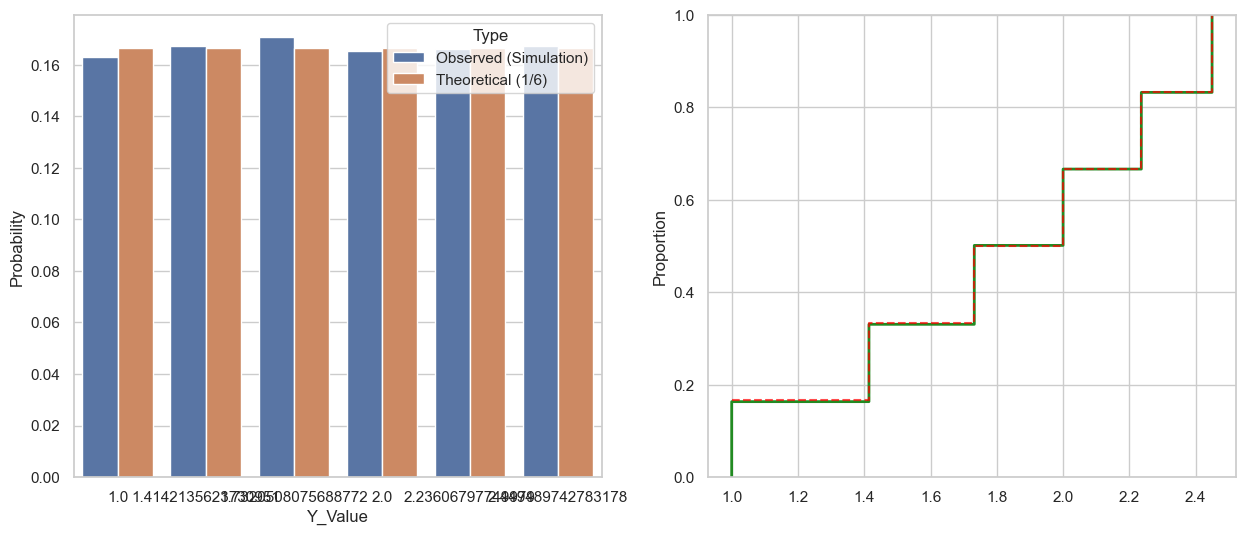

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns 
from collections import Counter


def calculate_random_variable(roll):
    return np.sqrt(roll)

N_TRIALS = 5000

rolls = np.random.randint(1, 7, size=N_TRIALS)


rv_values = calculate_random_variable(rolls)

unique_y, counts = np.unique(rv_values, return_counts=True)
observed_pmf = counts / N_TRIALS


theoretical_pmf = np.array([1/6] * len(unique_y))

pmf_data = pd.DataFrame({
    'Y_Value': np.concatenate([unique_y, unique_y]),
    'Probability': np.concatenate([observed_pmf, theoretical_pmf]),
    'Type': ['Observed (Simulation)'] * len(unique_y) + ['Theoretical (1/6)'] * len(unique_y)
})


theoretical_x = unique_y
theoretical_y = np.cumsum(theoretical_pmf)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


ax1 = axes[0]
sns.barplot(
    data=pmf_data,
    x='Y_Value',
    y='Probability',
    hue='Type',
    ax=ax1
)



ax2 = axes[1]


sns.ecdfplot(
    x=rv_values,
    ax=ax2,
    color='forestgreen',
    linewidth=2,
    label=f'Observed ECDF from {N_TRIALS} Rolls'
)


ax2.step(theoretical_x, theoretical_y, where='post', label='Theoretical CDF', linestyle='--', color='red', alpha=0.7)
plt.show()


**Write code to simulate the random variable (rolling two six-sided die and adding the results together). Simulate 10000 rolls and plot the mass function and ECDF.**

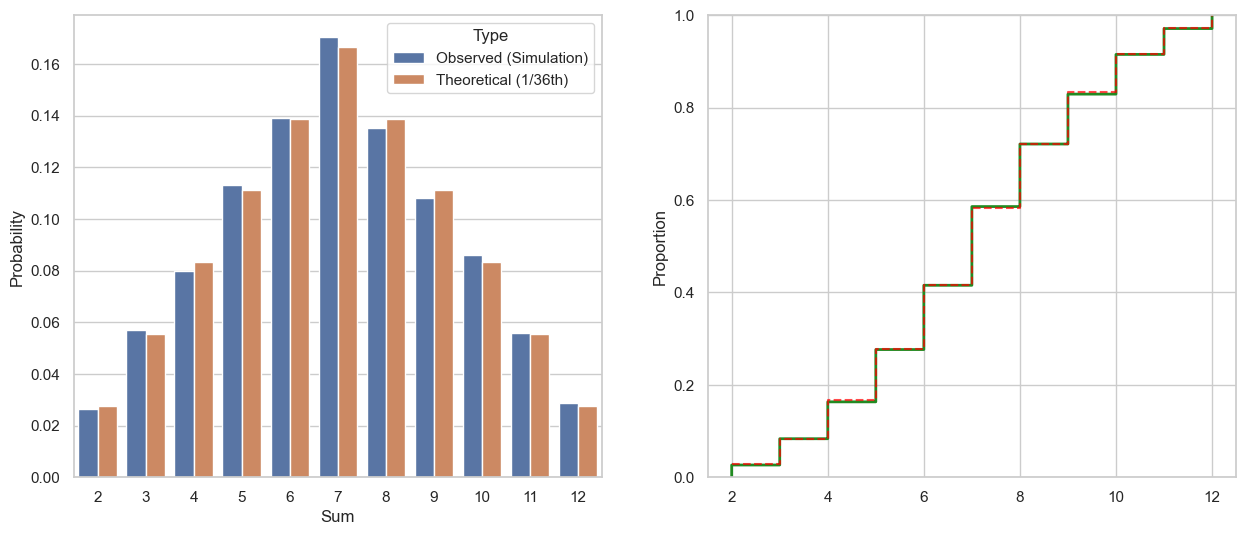

In [7]:
def calculate_random_variable(roll1, roll2):
    return roll1 + roll2


N_TRIALS = 10000

roll_d1 = np.random.randint(1, 7, size=N_TRIALS)
roll_d2 = np.random.randint(1, 7, size=N_TRIALS)


rv_values = calculate_random_variable(roll_d1, roll_d2)


possible_sums = np.arange(2, 13)


theoretical_counts = np.array([1, 2, 3, 4, 5, 6, 5, 4, 3, 2, 1])
theoretical_pmf = theoretical_counts / 36.0


observed_counts = Counter(rv_values)
observed_pmf = np.array([observed_counts.get(s, 0) / N_TRIALS for s in possible_sums])


pmf_data = pd.DataFrame({
    'Sum': np.concatenate([possible_sums, possible_sums]),
    'Probability': np.concatenate([observed_pmf, theoretical_pmf]),
    'Type': ['Observed (Simulation)'] * len(possible_sums) + ['Theoretical (1/36th)'] * len(possible_sums)
})


theoretical_x = possible_sums
theoretical_y = np.cumsum(theoretical_pmf)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))


ax1 = axes[0]
sns.barplot(
    data=pmf_data,
    x='Sum',
    y='Probability',
    hue='Type',
    ax=ax1
)


ax2 = axes[1]


sns.ecdfplot(
    x=rv_values,
    ax=ax2,
    color='forestgreen',
    linewidth=2,
    label=f'Observed ECDF from {N_TRIALS} Rolls'
)

ax2.step(theoretical_x, theoretical_y, where='post', label='Theoretical CDF', linestyle='--', color='red', alpha=0.7)


plt.show()

### 4. Roulette

This question will be easiest if you read the whole thing, and come up with a clear plan for how you'll write the code.

Roulette is a betting game. There are 37 possible outcomes: A green 0, and the numbers 1 to 36 in red and black. Here is a picture of the (American, not Euro, it has an extra green 00) betting board:

![Roulette](./src/euro_roulette.jpg)

To bet, you must pay a dollar, but then you get payouts that depend on how many slots are in your bet
- Basic bets:
    - Red or Black slots
    - Odd or Even slots
    - A single slots, like 20
- More complex bets:
    - Split: Two adjacent slots (e.g. {1,2})
    - Square: Four adjacent slots (e.g. {1,2,4,5})
    - Street: Three slots in a row (e.g. {1,2,3})
    - Line: Six slots (e.g. {1,2,3,4,5,6})
In general, you can only bet on 1, 2, 3, 4, 6 slots, 12 slots, or 18 slots. If your bet occurs when the wheel is spun, you gain 36/K-1 where $K$ is the number of slots you bet on; if not, you lose a dollar and get -1.

- Write code to model spinning the roulette wheel, including the colors and numbers (you could make two lists of number and color and draw a random number between 0 and 37... or use a dataframe with color and number variables and sample it... or use a dict with key to number/color pairs...)
- Describe the probability space associated with the roulette wheel: Outcomes, events, probabilities (If there are 37 outcomes, there are $2^{37}= 137,438,953,472$ events, by the way)
- You wrote code to generate a spin of the roulette wheel. Now write a function that takes a basic or complex bet as an argument, and returns the result for the player (win or lose, and the payout 36/K-1 or -1)
- Simulate betting on red, betting on odd, betting on 7, a split, and a line 1000 times each.
- Compute the average values for the bets you just simulated. What are the expected average payoffs?

0 green, 1-36 red/black --> 37 slots 

*pay off for winning is (36/k) - 1; pay off for losing is -1*


*probability to win is k/37 & probability to lose is 1 - (k/37)*


expected value of gamble: k/37(36/k - 1) + (1-k/37)(-1) = 36/37 - k/37 - 1 + k/37 = -1/37 
- expected value does not depend on k --> you will always expect a -1/37

In [ ]:
import random 


WHEEL = pd.DataFrame({
    'Slot': list(range(1, 37)) + [0, 99], 
    'Color': (['Red', 'Black'] * 18) + ['Green', 'Green']
})

SLOTS = {
    0: 'Green',
    '00': 'Green',
}
for i in range(1, 37):

    SLOTS[i] = 'Red' if i % 2 != 0 else 'Black'

SLOTS_LIST = list(range(1, 37)) + [0, '00']
COLOR_MAP = {
    0: 'Green',
    '00': 'Green',
    1: 'Red', 2: 'Black', 3: 'Red', 4: 'Black', 5: 'Red', 6: 'Black',
    7: 'Red', 8: 'Black', 9: 'Red', 10: 'Black', 11: 'Black', 12: 'Red',
    13: 'Black', 14: 'Red', 15: 'Black', 16: 'Red', 17: 'Black', 18: 'Red',
    19: 'Red', 20: 'Black', 21: 'Red', 22: 'Black', 23: 'Red', 24: 'Black',
    25: 'Red', 26: 'Black', 27: 'Red', 28: 'Black', 29: 'Black', 30: 'Red',
    31: 'Black', 32: 'Red', 33: 'Black', 34: 'Red', 35: 'Black', 36: 'Red'
}


def spin_wheel():
    return random.choice(SLOTS_LIST)

--- Probability Space of American Roulette (38 Slots) ---
1. Outcomes (Sample Space): 38 simple outcomes, each with probability P = 1/38.
   (Example Outcomes: 0, '00', 1, 2, ..., 36)
2. Space of Events: The power set of the 38 simple outcomes, totaling 2^38 = 274,877,906,944 events.
   (Example Events: 'Spin is Green' = {0, '00'}; 'Spin is 7' = {7})

--- Simulation Results and Expected Payoffs ---
                         Bet  K  Expected Payoff (E[X])  Simulated Average Payoff
           Bet on Red (K=18) 18                 -0.0526                   -0.0502
           Bet on Odd (K=18) 18                 -0.0526                   -0.0568
              Bet on 7 (K=1)  1                 -0.0526                   -0.0928
      Split Bet {4, 5} (K=2)  2                 -0.0526                   -0.0334
Line Bet {1,2,3,4,5,6} (K=6)  6                 -0.0526                   -0.0496


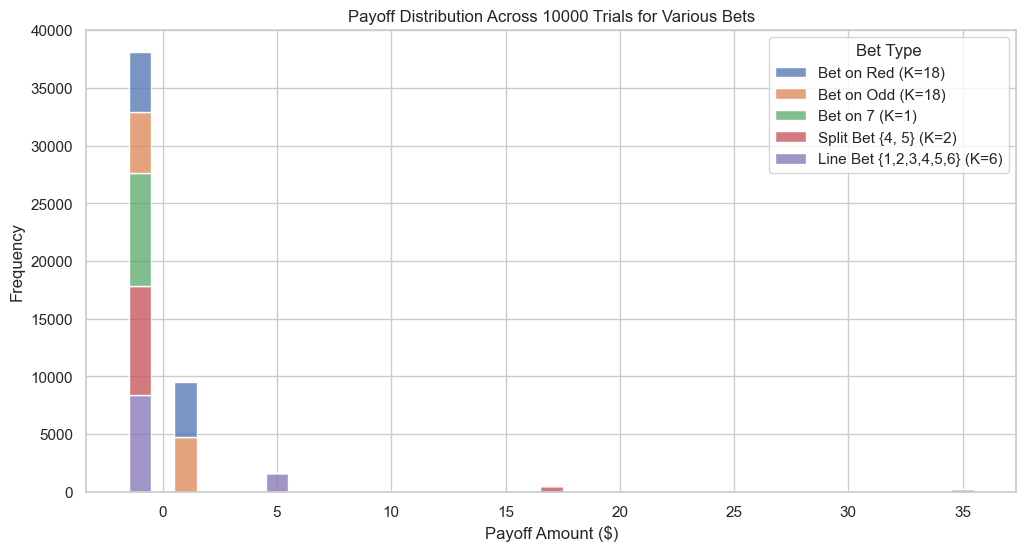

In [12]:

def check_bet(slot_result, bet_type, bet_value=None):
   
    K = 0
    is_win = False
    
    if bet_type == 'color':
        K = 18
        if bet_value == 'Red':
            is_win = (slot_result in range(1, 37) and COLOR_MAP[slot_result] == 'Red')
        elif bet_value == 'Black':
            is_win = (slot_result in range(1, 37) and COLOR_MAP[slot_result] == 'Black')
    
    elif bet_type == 'parity':
        K = 18
        if slot_result in range(1, 37):
            if bet_value == 'Odd':
                is_win = (slot_result % 2 != 0)
            elif bet_value == 'Even':
                is_win = (slot_result % 2 == 0)

 
    elif bet_type == 'single':
        K = 1
        is_win = (slot_result == bet_value)
    
    elif bet_type == 'split': 
        K = 2
        is_win = (slot_result in bet_value)
    
    elif bet_type == 'street': 
        K = 3
        is_win = (slot_result in bet_value)

    elif bet_type == 'square': 
        K = 4
        is_win = (slot_result in bet_value)
        
    elif bet_type == 'line': 
        K = 6
        is_win = (slot_result in bet_value)

    if is_win:
        payout = (36 / K) - 1
        return payout
    else:
        return -1


def simulate_bet(bet_params, num_trials):
    payoffs = []
    
    bet_type = bet_params['type']
    bet_value = bet_params['value']
    
    for _ in range(num_trials):
        spin = spin_wheel()
        payoff = check_bet(spin, bet_type, bet_value)
        payoffs.append(payoff)
    
    return np.array(payoffs)

print("--- Probability Space of American Roulette (38 Slots) ---")


OUTCOMES = SLOTS_LIST
N_OUTCOMES = 38
P_OUTCOME = 1 / N_OUTCOMES

print(f"1. Outcomes (Sample Space): {N_OUTCOMES} simple outcomes, each with probability P = 1/38.")
print(f"   (Example Outcomes: 0, '00', 1, 2, ..., 36)")


N_EVENTS = 2**N_OUTCOMES
print(f"2. Space of Events: The power set of the 38 simple outcomes, totaling 2^38 = {N_EVENTS:,} events.")
print(f"   (Example Events: 'Spin is Green' = {{0, '00'}}; 'Spin is 7' = {{7}})")


BET_CONFIGS = [
    {'name': 'Bet on Red (K=18)', 'type': 'color', 'value': 'Red', 'K': 18},
    {'name': 'Bet on Odd (K=18)', 'type': 'parity', 'value': 'Odd', 'K': 18},
    {'name': 'Bet on 7 (K=1)', 'type': 'single', 'value': 7, 'K': 1},
    {'name': 'Split Bet {4, 5} (K=2)', 'type': 'split', 'value': [4, 5], 'K': 2}, # Example split bet
    {'name': 'Line Bet {1,2,3,4,5,6} (K=6)', 'type': 'line', 'value': [1, 2, 3, 4, 5, 6], 'K': 6}, # Example line bet
]

N_SIMULATIONS = 10000 

results = []

print("\n--- Simulation Results and Expected Payoffs ---")

for bet in BET_CONFIGS:
    K = bet['K']
    P_win = K / N_OUTCOMES
    P_lose = (N_OUTCOMES - K) / N_OUTCOMES
    Payout_win = (36 / K) - 1
    expected_payoff = (P_win * Payout_win) + (P_lose * -1)
    
    payoffs = simulate_bet(bet, N_SIMULATIONS)
    average_payoff_sim = np.mean(payoffs)
    
    results.append({
        'Bet': bet['name'],
        'K': K,
        'Expected Payoff (E[X])': expected_payoff,
        'Simulated Average Payoff': average_payoff_sim
    })


results_df = pd.DataFrame(results)
print(results_df.to_string(index=False, float_format="{:.4f}".format))


plt.figure(figsize=(12, 6))

payoff_data = []
for bet in BET_CONFIGS:
    payoffs = simulate_bet(bet, N_SIMULATIONS)
    for p in payoffs:
        payoff_data.append({'Bet Type': bet['name'], 'Payoff': p})

payoff_df = pd.DataFrame(payoff_data)

sns.histplot(
    data=payoff_df, 
    x='Payoff', 
    hue='Bet Type', 
    multiple='stack', 
    bins=np.arange(-1.5, 36.5, 1), 
    edgecolor='white'
)

plt.title(f'Payoff Distribution Across {N_SIMULATIONS} Trials for Various Bets')
plt.xlabel('Payoff Amount ($)')
plt.ylabel('Frequency')
plt.show()


### 5. CDF and PDF Basics

- Verify the following functions are distribution functions and compute their density functions. Plot the distribution and density.

1. $F(x) = \begin{cases}
0, & x \le 0 \\
\sqrt{x}, & 0 \le x \le 1 \\
1, & x \ge 1 
\end{cases}
$
2. $F(x) = \dfrac{1}{1+e^{-x}}$
3. For $ a < b < c$,
$
F(x) = \begin{cases}
0, & x \le 0 \\
\frac{(x-a)^2}{(b-a)(b-c)}, & a \le x \le c \\
1 - \frac{(b-x)^2}{(b-a)(b-c)}, & c < x < b \\
1, & x \ge b
\end{cases}
$
4. $ F(x) = \begin{cases}
0, & x <0 \\
1 - e^{-x}, & x>0
\end{cases}
$
5. $ F(x) = \begin{cases}
0, & x \le 0 \\
x, & 0 < x < 1\\
1, & x \ge 1
\end{cases}
$

### 6. Some Common Distributions

For the following distributions:
- Determine the support
- Compute the density from the distribution for the logistic and exponential distributions (take a derivative)
- Plot the density and distribution for a variety of parameter values
- Take a sample of 1000 draws $(x_1, x_2, ..., x_{1000})$ from the distribution, plot a KDE and ECDF, visually compare with the theoretical pdf/cdf
- Find an example of this general type of PDF/CDF from the Metabric cancer data

You can use https://docs.scipy.org/doc/scipy/reference/stats.html to generate values for the pdf/cdf and generate samples of random variates.


- Logistic distribution (similar to normal): 
$$
F(x; \sigma) = \dfrac{1}{1+e^{-x/\sigma}} 
$$
with $\sigma >0$.
- Exponential distribution (similar to log-normal):
$$
F_X(x) = \begin{cases}
0, & x<0 \\
1 - e^{-\lambda x}, & x \ge 0,
\end{cases}
$$
with $\lambda > 0$.
- Negative Binomial (similar to Poisson): The probability mass function for positive integers is:
$$
f(k;r,p) = \dfrac{(k+r-1)!}{k!(r-1)!}(1-p)^k p^r, \quad \text{ for $k=0,...n$}
$$
You can interpret this as follows: Flip a coin that comes up heads with probability $p$ until you get $r$ heads, and then stop. What is the probability of stopping at each $k=0,1,2,...$?
- Categorical (similar to Bernoulli): The probability mass function over $k = 1, 2, ..., K$ categories is
$$
f(k;p_1,...,p_K) = p_1^{k=1}p_2^{k=2}...p_K^{k=K}
$$
where $0 \le p_i \le 1$ and $ \sum_{k=1}^K p_k = 1$.


               PROBABILITY DISTRIBUTION ANALYSIS


<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:81: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\l'
<>:81: SyntaxWarning: invalid escape sequence '\l'
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_21151/2482058273.py:23: SyntaxWarning: invalid escape sequence '\s'
  fig.suptitle(f'Logistic Distribution: $\sigma={sigma_val}$, Support: {support}', y=1.05)
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_21151/2482058273.py:40: SyntaxWarning: invalid escape sequence '\s'
  print(f"\nLogistic Distribution ($\sigma={sigma_val}$):")
/var/folders/v1/c8q_17915_v735dr_k_2fb7w0000gn/T/ipykernel_21151/2482058273.py:60: SyntaxWarning: invalid escape sequence '\l'
  fig.suptitle(f'Exponential Distribution: $\lambda={lambda_

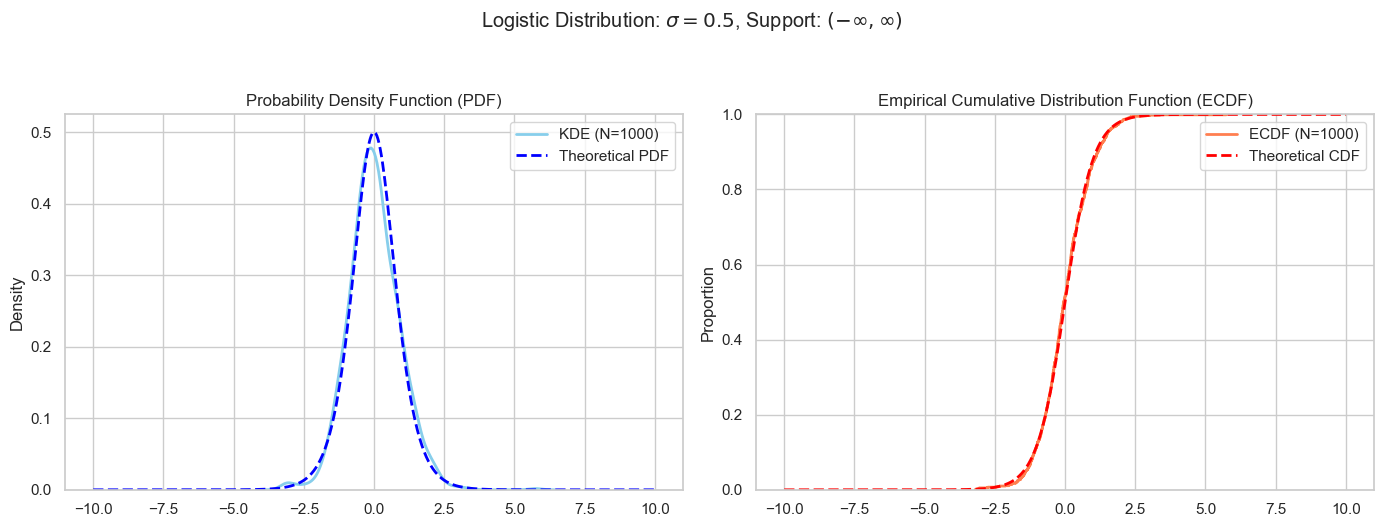


Logistic Distribution ($\sigma=0.5$):
  Support: $(-\infty, \infty)$
  Theoretical PDF: $f(x; \sigma) = \frac{e^{-x/\sigma}}{\sigma (1+e^{-x/\sigma})^2}$
  Metabric Example Type: Residuals of symmetric survival/time-to-event models (Continuous)


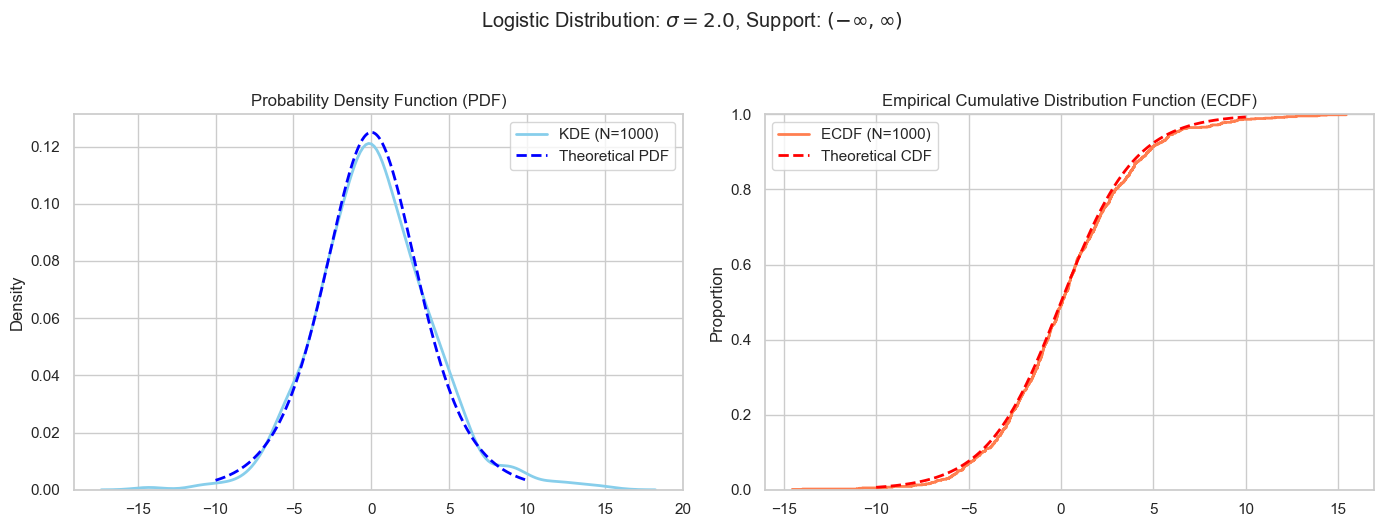


Logistic Distribution ($\sigma=2.0$):
  Support: $(-\infty, \infty)$
  Theoretical PDF: $f(x; \sigma) = \frac{e^{-x/\sigma}}{\sigma (1+e^{-x/\sigma})^2}$
  Metabric Example Type: Residuals of symmetric survival/time-to-event models (Continuous)


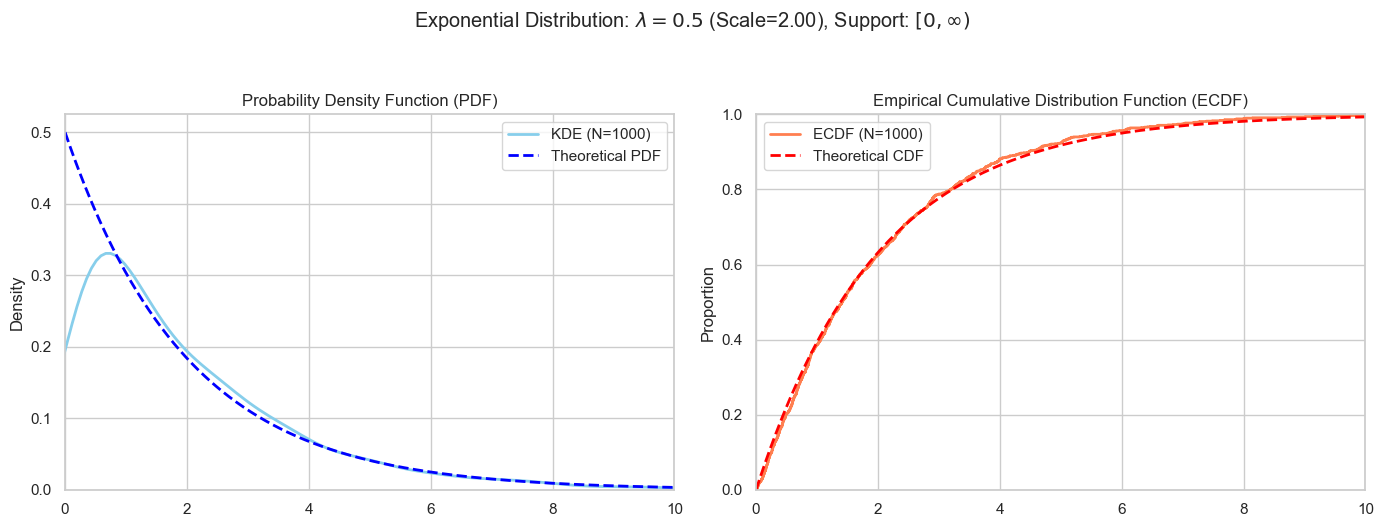


Exponential Distribution ($\lambda=0.5$):
  Support: $[0, \infty)$
  Theoretical PDF: $f(x; \lambda) = \lambda e^{-\lambda x}, \text{ for } x \ge 0$
  Metabric Example Type: Time until recurrence/death (Survival Time, Continuous)


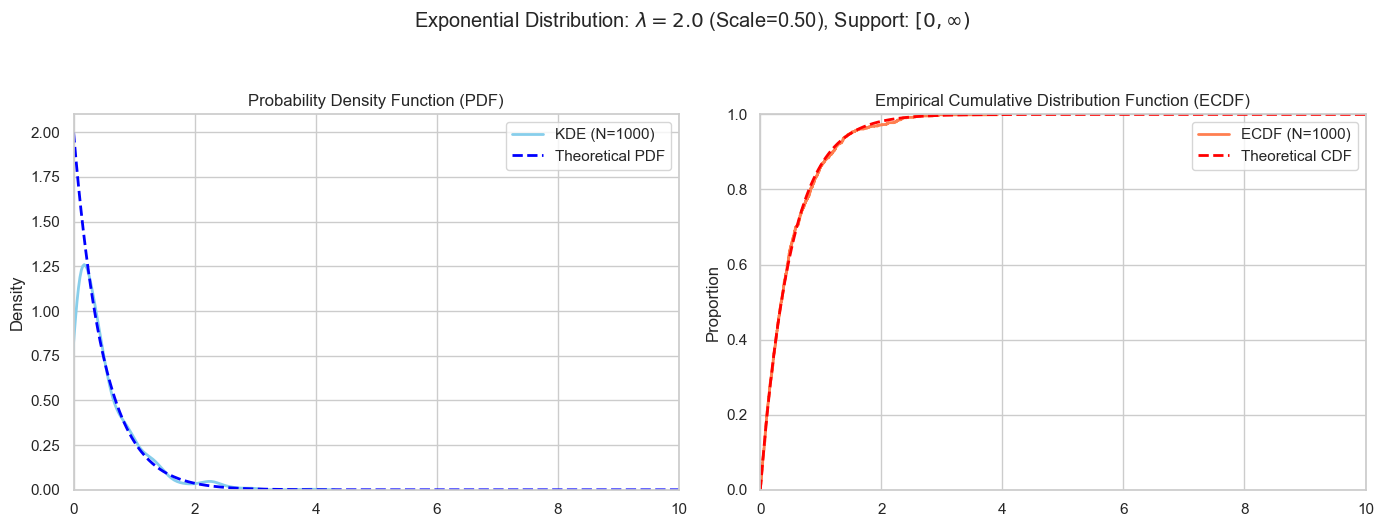


Exponential Distribution ($\lambda=2.0$):
  Support: $[0, \infty)$
  Theoretical PDF: $f(x; \lambda) = \lambda e^{-\lambda x}, \text{ for } x \ge 0$
  Metabric Example Type: Time until recurrence/death (Survival Time, Continuous)


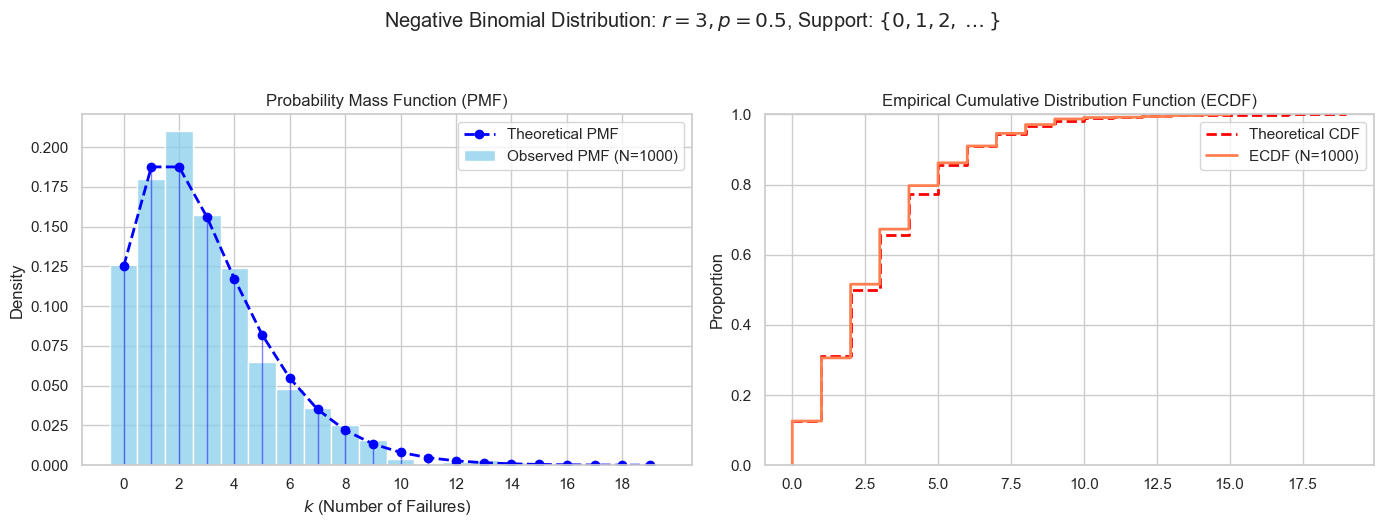


Negative Binomial Distribution ($r=3, p=0.5$):
  Support: $\{0, 1, 2, \dots\}$
  Theoretical PMF: $f(k;r,p) = \dfrac{(k+r-1)!}{k!(r-1)!}(1-p)^k p^r$
  Metabric Example Type: Number of failed treatments before successful outcome (Count Data, Discrete)


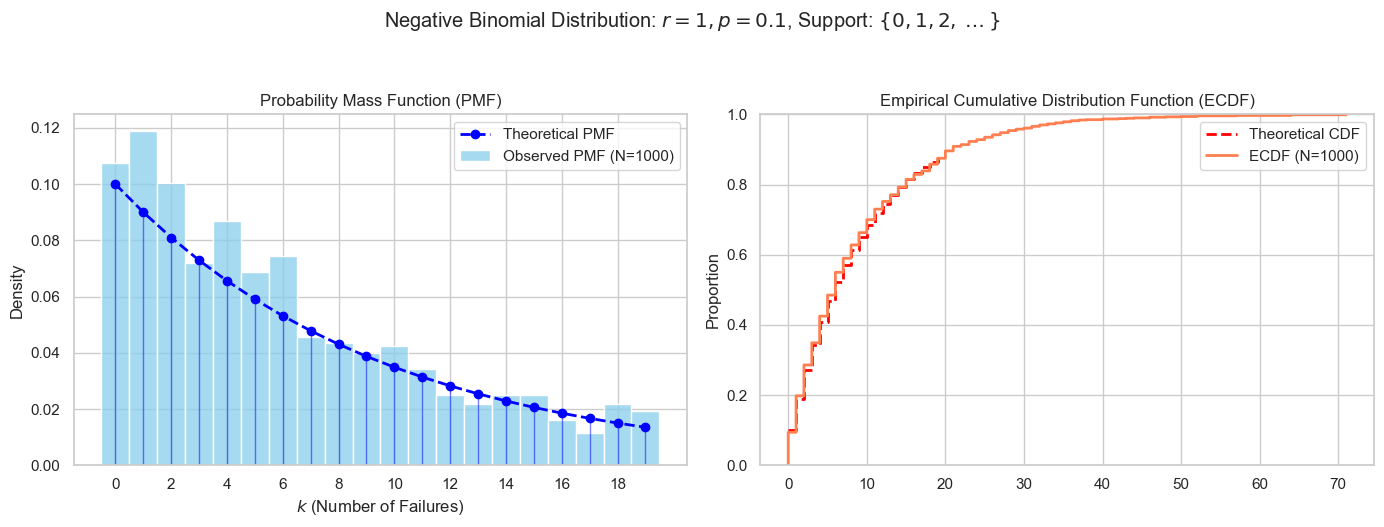


Negative Binomial Distribution ($r=1, p=0.1$):
  Support: $\{0, 1, 2, \dots\}$
  Theoretical PMF: $f(k;r,p) = \dfrac{(k+r-1)!}{k!(r-1)!}(1-p)^k p^r$
  Metabric Example Type: Number of failed treatments before successful outcome (Count Data, Discrete)


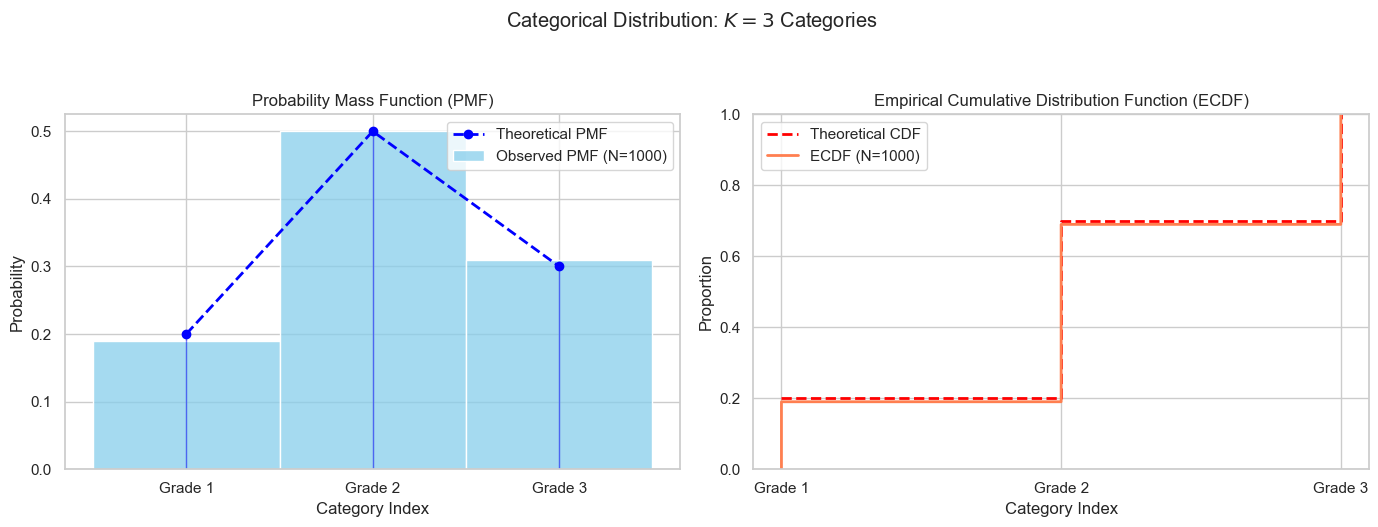


Categorical Distribution (Probabilities=[0.2, 0.5, 0.3]):
  Support: $\{1, 2, \dots, K\}$
  Theoretical PMF: $f(k;p_1,\dots,p_K) = p_k \text{ if } k \text{ is selected}$
  Metabric Example Type: Tumor Grade or Receptor Status (Categorical, Discrete)



In [15]:
from scipy.stats import logistic, expon, nbinom, rv_discrete




N_DRAWS = 1000
X_PLOT = np.linspace(-10, 10, 500) 
X_PLOT_POS = np.linspace(0, 10, 500) 
K_MAX_DISCRETE = 20 


def analyze_logistic(sigma_val, loc_val=0, ax_offset=0):
    support = r'$(-\infty, \infty)$'
    pdf_formula = r'$f(x; \sigma) = \frac{e^{-x/\sigma}}{\sigma (1+e^{-x/\sigma})^2}$'
    example_type = 'Residuals of symmetric survival/time-to-event models (Continuous)'
    dist = logistic(loc=loc_val, scale=sigma_val)
    theoretical_pdf = dist.pdf(X_PLOT)
    theoretical_cdf = dist.cdf(X_PLOT)

    sample_draws = dist.rvs(size=N_DRAWS)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Logistic Distribution: $\sigma={sigma_val}$, Support: {support}', y=1.05)
    
    ax1 = axes[0]
    sns.kdeplot(sample_draws, ax=ax1, label=f'KDE (N={N_DRAWS})', linewidth=2, color='skyblue')
    ax1.plot(X_PLOT, theoretical_pdf, label='Theoretical PDF', color='blue', linestyle='--', linewidth=2)
    ax1.set_title(f'Probability Density Function (PDF)')
    ax1.legend()

    ax2 = axes[1]
    sns.ecdfplot(sample_draws, ax=ax2, label=f'ECDF (N={N_DRAWS})', linewidth=2, color='coral')
    ax2.plot(X_PLOT, theoretical_cdf, label='Theoretical CDF', color='red', linestyle='--', linewidth=2)
    ax2.set_title('Empirical Cumulative Distribution Function (ECDF)')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    print(f"\nLogistic Distribution ($\sigma={sigma_val}$):")
    print(f"  Support: {support}")
    print(f"  Theoretical PDF: {pdf_formula}")
    print(f"  Metabric Example Type: {example_type}")


def analyze_exponential(lambda_val, ax_offset=0):
    support = r'$[0, \infty)$'
    pdf_formula = r'$f(x; \lambda) = \lambda e^{-\lambda x}, \text{ for } x \ge 0$'
    example_type = 'Time until recurrence/death (Survival Time, Continuous)'
    scale_val = 1 / lambda_val
    dist = expon(scale=scale_val)
    theoretical_pdf = dist.pdf(X_PLOT_POS)
    theoretical_cdf = dist.cdf(X_PLOT_POS)


    sample_draws = dist.rvs(size=N_DRAWS)


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Exponential Distribution: $\lambda={lambda_val}$ (Scale={scale_val:.2f}), Support: {support}', y=1.05)


    ax1 = axes[0]
    sns.kdeplot(sample_draws, ax=ax1, label=f'KDE (N={N_DRAWS})', linewidth=2, color='skyblue')
    sns.lineplot(x=X_PLOT_POS, y=theoretical_pdf, ax=ax1, label='Theoretical PDF', color='blue', linestyle='--', linewidth=2)
    ax1.set_title(f'Probability Density Function (PDF)')
    ax1.set_xlim(0, 10)
    ax1.legend()


    ax2 = axes[1]
    sns.ecdfplot(sample_draws, ax=ax2, label=f'ECDF (N={N_DRAWS})', linewidth=2, color='coral')
    sns.lineplot(x=X_PLOT_POS, y=theoretical_cdf, ax=ax2, label='Theoretical CDF', color='red', linestyle='--', linewidth=2)
    ax2.set_title('Empirical Cumulative Distribution Function (ECDF)')
    ax2.set_xlim(0, 10)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    print(f"\nExponential Distribution ($\lambda={lambda_val}$):")
    print(f"  Support: {support}")
    print(f"  Theoretical PDF: {pdf_formula}")
    print(f"  Metabric Example Type: {example_type}")


def analyze_nbinom(r_val, p_val, ax_offset=0):
    support = r'$\{0, 1, 2, \dots\}$'
    pmf_formula = r'$f(k;r,p) = \dfrac{(k+r-1)!}{k!(r-1)!}(1-p)^k p^r$'
    example_type = 'Number of failed treatments before successful outcome (Count Data, Discrete)'
    dist = nbinom(r_val, p_val)
    k_vals = np.arange(K_MAX_DISCRETE)
    theoretical_pmf = dist.pmf(k_vals)
    theoretical_cdf = dist.cdf(k_vals)
    sample_draws = dist.rvs(size=N_DRAWS)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Negative Binomial Distribution: $r={r_val}, p={p_val}$, Support: {support}', y=1.05)
    ax1 = axes[0]
    sns.histplot(sample_draws, bins=np.arange(K_MAX_DISCRETE + 1) - 0.5, stat='density', ax=ax1, label=f'Observed PMF (N={N_DRAWS})', color='skyblue')
    ax1.plot(k_vals, theoretical_pmf, 'o', label='Theoretical PMF', color='blue', linestyle='--', linewidth=2)
    ax1.vlines(k_vals, 0, theoretical_pmf, colors='blue', lw=1, alpha=0.5)
    ax1.set_title(f'Probability Mass Function (PMF)')
    ax1.set_xlabel('$k$ (Number of Failures)')
    ax1.set_xticks(np.arange(0, K_MAX_DISCRETE, 2))
    ax1.legend()


    ax2 = axes[1]
    ax2.step(k_vals, theoretical_cdf, where='post', label='Theoretical CDF', color='red', linestyle='--', linewidth=2)
    sns.ecdfplot(sample_draws, ax=ax2, label=f'ECDF (N={N_DRAWS})', linewidth=2, color='coral')
    ax2.set_title('Empirical Cumulative Distribution Function (ECDF)')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    print(f"\nNegative Binomial Distribution ($r={r_val}, p={p_val}$):")
    print(f"  Support: {support}")
    print(f"  Theoretical PMF: {pmf_formula}")
    print(f"  Metabric Example Type: {example_type}")

def analyze_categorical(probabilities, labels):
    support = r'$\{1, 2, \dots, K\}$'
    pmf_formula = r'$f(k;p_1,\dots,p_K) = p_k \text{ if } k \text{ is selected}$'
    example_type = 'Tumor Grade or Receptor Status (Categorical, Discrete)'
    
    if round(sum(probabilities), 5) != 1.0:
        raise ValueError("Probabilities must sum to 1.0 for Categorical distribution.")

    k_vals = np.arange(1, len(probabilities) + 1)
    theoretical_pmf = probabilities
    theoretical_cdf = np.cumsum(probabilities)


    sample_draws = np.random.choice(k_vals, size=N_DRAWS, p=probabilities)


    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Categorical Distribution: $K={len(probabilities)}$ Categories', y=1.05)
    
    ax1 = axes[0]
    sns.histplot(sample_draws, bins=np.arange(0.5, len(probabilities) + 1.5, 1), stat='probability', ax=ax1, label=f'Observed PMF (N={N_DRAWS})', color='skyblue')
    ax1.plot(k_vals, theoretical_pmf, 'o', label='Theoretical PMF', color='blue', linestyle='--', linewidth=2)
    ax1.vlines(k_vals, 0, theoretical_pmf, colors='blue', lw=1, alpha=0.5)
    ax1.set_title(f'Probability Mass Function (PMF)')
    ax1.set_xlabel('Category Index')
    ax1.set_xticks(k_vals)
    ax1.set_xticklabels(labels)
    ax1.legend()

    ax2 = axes[1]
    ax2.step(k_vals, theoretical_cdf, where='post', label='Theoretical CDF', color='red', linestyle='--', linewidth=2)
    sns.ecdfplot(sample_draws, ax=ax2, label=f'ECDF (N={N_DRAWS})', linewidth=2, color='coral')
    ax2.set_title('Empirical Cumulative Distribution Function (ECDF)')
    ax2.set_xlabel('Category Index')
    ax2.set_xticks(k_vals)
    ax2.set_xticklabels(labels)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    print(f"\nCategorical Distribution (Probabilities={probabilities}):")
    print(f"  Support: {support}")
    print(f"  Theoretical PMF: {pmf_formula}")
    print(f"  Metabric Example Type: {example_type}")

if __name__ == '__main__':
    print("=====================================================")
    print("               PROBABILITY DISTRIBUTION ANALYSIS")
    print("=====================================================")
    

    analyze_logistic(sigma_val=0.5)
    analyze_logistic(sigma_val=2.0)
    

    analyze_exponential(lambda_val=0.5)
    analyze_exponential(lambda_val=2.0)
    

    analyze_nbinom(r_val=3, p_val=0.5) 
    analyze_nbinom(r_val=1, p_val=0.1) 
    
    analyze_categorical(probabilities=[0.2, 0.5, 0.3], labels=['Grade 1', 'Grade 2', 'Grade 3'])
    
    print("\n=====================================================")